In [ ]:
import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt

import gpjax as gpx
import optax as ox
import paramax as px

from non_parametric_pro import ula

from non_parametric_pro.density import ProParameters, pro_logdensity_fn, pro_score_fn
from non_parametric_pro.ula import parametric_ula
from non_parametric_pro.util import prediction_basis, nlpd_gp, nlpd_pro, crps_gp, crps_pro
from non_parametric_pro.data.uci import load_uci_regression_dataset
from non_parametric_pro.adaptation.parameter_adaptation import parameter_adaptation
from non_parametric_pro.gp import _full_gp_basis
from non_parametric_pro.util import train_val_split


from blackjax.util import run_inference_algorithm

from sklearn.preprocessing import StandardScaler

jax.config.update("jax_enable_x64", True)

In [185]:
key = jr.PRNGKey(1)

example = load_uci_regression_dataset("forest", split=3)

scaler_x = StandardScaler()
scaler_y = StandardScaler()

x_full = scaler_x.fit_transform(example.x_train)
y_full = scaler_y.fit_transform(example.y_train)

split = train_val_split(key, x_full, y_full, val_fraction=0.2)
x_train, y_train = split.x_train, split.y_train
x_val, y_val = split.x_val, split.y_val

x_test = scaler_x.transform(example.x_test)
y_test = scaler_y.transform(example.y_test)

In [186]:
D = x_train.shape[1]

data = gpx.Dataset(X=x_full, y=y_full)
# kernel = gpx.kernels.Matern32(lengthscale=jnp.ones((D,)))
kernel = gpx.kernels.Matern32(lengthscale=jnp.ones((D,)), variance=px.NonTrainable(jnp.array(1.0)))

prior = gpx.gps.Prior(mean_function=gpx.mean_functions.Zero(), kernel=kernel)
likelihood = gpx.likelihoods.Gaussian(num_datapoints=data.n)
posterior = prior * likelihood

optim = ox.adam(learning_rate=0.1)

gp_posterior, _ = gpx.fit(
    model=posterior,
    objective=lambda p, d: -gpx.objectives.conjugate_mll(p, d),
    train_data=data,
    optim=optim,
    num_iters=200,
    verbose=False,
)

gp_latent_dist = gp_posterior.predict(x_test, train_data=data)
gp_predictive_dist = gp_posterior.likelihood(gp_latent_dist)

gp_predictive_mean = gp_predictive_dist.mean
gp_predictive_std = jnp.sqrt(gp_predictive_dist.variance)

gp_sigma = gp_posterior.likelihood.obs_stddev
gp_kernel = gp_posterior.prior.kernel

print("GP NLPD:", nlpd_gp(y_test, gp_predictive_mean, gp_predictive_std))
print("GP sigma", px.unwrap(gp_sigma))

GP NLPD: 1.25881412256617
GP sigma 0.4175346455776404


Running parameter adaptation


<div><progress max="6000" value="6000"></progress> 100.00% [6000/6000 00:00&lt;?]</div>

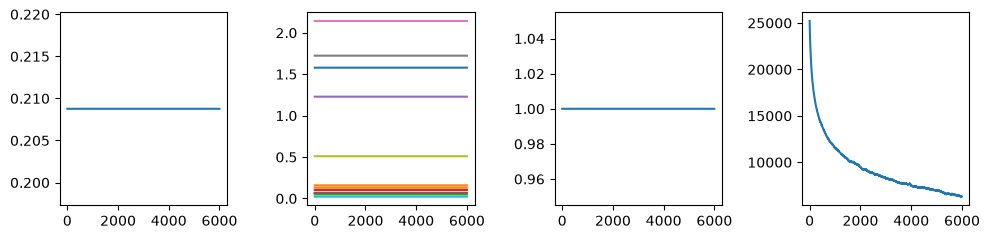

In [195]:
adapt = True

M = x_train.shape[0]
basis, residual_std = _full_gp_basis(gp_posterior, x_train), None

sigma = gpx.parameters.SigmoidBounded(px.unwrap(gp_sigma) / 2, low=0.15, high=100.0)

pro_params = ProParameters(
    y=y_train,
    basis=basis,
    step_size=1e-4,
    sigma=sigma,
    alpha=1.0,
    residual_std=residual_std
)

J = 50

initial_position = jr.normal(key, (M, J))

if adapt:

    adaptation = parameter_adaptation(
        ula,
        pro_logdensity_fn,
        pro_params,
        x_train=x_train,
        initial_kernel=gp_kernel,
        warmup_steps=1000,
        sigma_adapt_every=-1,
        kernel_adapt_every=-1,
        objective_fn=pro_score_fn,
        inducing_basis=None,
        sigma_optimizer=ox.adam(1e-1),
        kernel_optimizer=ox.adam(1e-2),
        x_val=x_val,
        y_val=y_val,
        progress_bar=True
    ) 

    adaptation_results, adaptation_info = adaptation.run(key, initial_position, num_steps=6000)
    pro_kernel = jax.tree.map(lambda x: x[-1], adaptation_info.kernel)
    pro_params = adaptation_results.parameters
    pro_position = adaptation_results.state.position

    fig, ax = plt.subplots(1, 4, figsize=(10, 2.5))

    ax[0].plot(px.unwrap(adaptation_info.sigma))
    ax[1].plot(px.unwrap(adaptation_info.kernel.lengthscale))
    ax[2].plot(px.unwrap(adaptation_info.kernel.variance))
    ax[3].plot(-adaptation_info.sampler_info.score[10:])
    plt.tight_layout()
    plt.show()

In [196]:
basis = _full_gp_basis(gp_posterior, x_full)
M = x_full.shape[0]

pro_params = pro_params._replace(basis=basis)
pro_params = pro_params._replace(y=y_full)

<div><progress max="10000" value="10000"></progress> 100.00% [10000/10000 00:00&lt;?]</div>

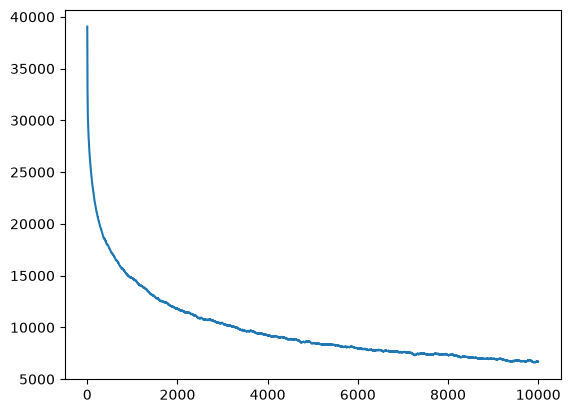

In [197]:
num_steps = 10000

initial_position = jr.normal(key, (M, J))
algorithm = parametric_ula(pro_logdensity_fn, pro_params)

out, info = run_inference_algorithm(
    rng_key=key,
    inference_algorithm=algorithm,
    num_steps=num_steps,
    initial_position=initial_position,
    progress_bar=True
)

plt.plot(-info[1].score)
plt.show()

In [198]:
burn_ratio = 0.8
thin = 50

burn = int(num_steps * burn_ratio)

particles = info[0].position[burn::thin]

test_basis, test_cov = prediction_basis(gp_kernel, x_full, x_test, pro_params)

print("PRO NLPD:", nlpd_pro(y_test, test_basis, test_cov, particles, parameters=pro_params))
print("GP NLPD:", nlpd_gp(y_test, gp_predictive_mean, gp_predictive_std))

PRO NLPD: 1.2640843036241272
GP NLPD: 1.25881412256617


In [114]:
print("PRO CRPS:", crps_pro(example.y_test, test_basis, test_cov, out.position, sigma=pro_params.sigma))
print("GP CRPS:", crps_gp(example.y_test, gp_predictive_mean, gp_predictive_std))

PRO CRPS: 0.21941324670620618
GP CRPS: 0.25637245520073243


In [ ]:
# algorithm = blackjax.mala(
#     lambda z: pro_logdensity_fn(z, adaptation_params if adapt else pro_params),
#     adaptation_params.step_size if adapt else pro_params.step_size,
# )
